# Lab 8: Define and Solve an ML Problem of Your Choosing

In [1]:
import pandas as pd
import numpy as np
import os 
import matplotlib.pyplot as plt
import seaborn as sns

In this lab assignment, you will follow the machine learning life cycle and implement a model to solve a machine learning problem of your choosing. You will select a data set and choose a predictive problem that the data set supports.  You will then inspect the data with your problem in mind and begin to formulate a  project plan. You will then implement the machine learning project plan. 

You will complete the following tasks:

1. Build Your DataFrame
2. Define Your ML Problem
3. Perform exploratory data analysis to understand your data.
4. Define Your Project Plan
5. Implement Your Project Plan:
    * Prepare your data for your model.
    * Fit your model to the training data and evaluate your model.
    * Improve your model's performance.

## Part 1: Build Your DataFrame

You will have the option to choose one of four data sets that you have worked with in this program:

* The "census" data set that contains Census information from 1994: `censusData.csv`
* Airbnb NYC "listings" data set: `airbnbListingsData.csv`
* World Happiness Report (WHR) data set: `WHR2018Chapter2OnlineData.csv`
* Book Review data set: `bookReviewsData.csv`

Note that these are variations of the data sets that you have worked with in this program. For example, some do not include some of the preprocessing necessary for specific models. 

#### Load a Data Set and Save it as a Pandas DataFrame

The code cell below contains filenames (path + filename) for each of the four data sets available to you.

<b>Task:</b> In the code cell below, use the same method you have been using to load the data using `pd.read_csv()` and save it to DataFrame `df`. 

You can load each file as a new DataFrame to inspect the data before choosing your data set.

In [2]:
# File names of the four data sets
adultDataSet_filename = os.path.join(os.getcwd(), "data", "censusData.csv")
airbnbDataSet_filename = os.path.join(os.getcwd(), "data", "airbnbListingsData.csv")
WHRDataSet_filename = os.path.join(os.getcwd(), "data", "WHR2018Chapter2OnlineData.csv")
bookReviewDataSet_filename = os.path.join(os.getcwd(), "data", "bookReviewsData.csv")


df = pd.read_csv(bookReviewDataSet_filename)

df.head()

,Review,Positive Review
0,This was perhaps the best of Johannes Steinhof...,True
1,This very fascinating book is a story written ...,True
2,The four tales in this collection are beautifu...,True
3,The book contained more profanity than I expec...,False
4,We have now entered a second time of deep conc...,True


## Part 2: Define Your ML Problem

Next you will formulate your ML Problem. In the markdown cell below, answer the following questions:

1. List the data set you have chosen.
2. What will you be predicting? What is the label?
3. Is this a supervised or unsupervised learning problem? Is this a clustering, classification or regression problem? Is it a binary classificaiton or multi-class classifiction problem?
4. What are your features? (note: this list may change after your explore your data)
5. Explain why this is an important problem. In other words, how would a company create value with a model that predicts this label?

<b>1.</b> I chose the Book Review DataSet.<br>
<b>2.</b> I will be predicting if the book's review is positive or not. The label will be 'Positive_Review'.<br>
<b>3.</b> This will be a supervised learning problem because usage of labels. This is a classification problem and it binary classification, with a True or False value.<br>
<b>4.</b> We will be using the feature 'Review'.<br>
<b>5.</b> This problem is useful because it can predict the positive and negative feedback that a book receives. This means publishers can get the sentiment of customers towards different books and see which genres are better, leading to reccomendations of that book or author. Allowing for personalized advertisments or leading retailers to put the books in common areas for more readers to access.

## Part 3: Understand Your Data

The next step is to perform exploratory data analysis. Inspect and analyze your data set with your machine learning problem in mind. Consider the following as you inspect your data:

1. What data preparation techniques would you like to use? These data preparation techniques may include:

    * addressing missingness, such as replacing missing values with means
    * finding and replacing outliers
    * renaming features and labels
    * finding and replacing outliers
    * performing feature engineering techniques such as one-hot encoding on categorical features
    * selecting appropriate features and removing irrelevant features
    * performing specific data cleaning and preprocessing techniques for an NLP problem
    * addressing class imbalance in your data sample to promote fair AI
    

2. What machine learning model (or models) you would like to use that is suitable for your predictive problem and data?
    * Are there other data preparation techniques that you will need to apply to build a balanced modeling data set for your problem and model? For example, will you need to scale your data?
 
 
3. How will you evaluate and improve the model's performance?
    * Are there specific evaluation metrics and methods that are appropriate for your model?
    

Think of the different techniques you have used to inspect and analyze your data in this course. These include using Pandas to apply data filters, using the Pandas `describe()` method to get insight into key statistics for each column, using the Pandas `dtypes` property to inspect the data type of each column, and using Matplotlib and Seaborn to detect outliers and visualize relationships between features and labels. If you are working on a classification problem, use techniques you have learned to determine if there is class imbalance.

<b>Task</b>: Use the techniques you have learned in this course to inspect and analyze your data. You can import additional packages that you have used in this course that you will need to perform this task.

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-drown menu.

In [3]:
df['Positive Review'].value_counts() #Checking Class Imbalances

False    993
True     980
Name: Positive Review, dtype: int64

In [4]:
df.isna().sum() #Checking for any null values or reviews that are not available

Review             0
Positive Review    0
dtype: int64

<b>Based on our analysis, as there was only one feature - we will do these steps going forward.</b>

1. Data Preparation -
   * Convert all text to lowercase.
   * Format Column Names.
   * Vectorize the Review Text.
2. We will be using A neural network for this dataset -
3. Evaluation -
   * We will evaluate this model using loss and accuracy given to us after compiling the model.
   * We will also visualize the loss and accuracy for the training and validation set.

## Part 4: Define Your Project Plan

Now that you understand your data, in the markdown cell below, define your plan to implement the remaining phases of the machine learning life cycle (data preparation, modeling, evaluation) to solve your ML problem. Answer the following questions:

* Do you have a new feature list? If so, what are the features that you chose to keep and remove after inspecting the data? 
* Explain different data preparation techniques that you will use to prepare your data for modeling.
* What is your model (or models)?
* Describe your plan to train your model, analyze its performance and then improve the model. That is, describe your model building, validation and selection plan to produce a model that generalizes well to new data. 

<b>We don't have a new feature list but we renamed the columns for better formatting and readability. We are using 'Book_Review' as our feature. We will be using TF-IDF to vectorize the words in the documents into vectors so it can be read for our model. We will be using a neural network as the model because We need a complex model that can be trained for sentiment analysis to find patterns that other models won't be able. The plan is to vectorize the features and then train a neural network, then record what we got and go back to tweak the model to keep improving it. We will add dropout layers or change epochs so that the model doesn't overfit and can generalize to new data.

## Part 5: Implement Your Project Plan

<b>Task:</b> In the code cell below, import additional packages that you have used in this course that you will need to implement your project plan.

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import tensorflow.keras as keras
from keras.wrappers.scikit_learn import KerasClassifier
from sklearn.model_selection import GridSearchCV
import time

<b>Task:</b> Use the rest of this notebook to carry out your project plan. 

You will:

1. Prepare your data for your model.
2. Fit your model to the training data and evaluate your model.
3. Improve your model's performance by performing model selection and/or feature selection techniques to find best model for your problem.

Add code cells below and populate the notebook with commentary, code, analyses, results, and figures as you see fit. 

In [6]:
df['Review'] = df['Review'].str.lower() # Turning all letters into lowercase
df['Review']

0       this was perhaps the best of johannes steinhof...
1       this very fascinating book is a story written ...
2       the four tales in this collection are beautifu...
3       the book contained more profanity than i expec...
4       we have now entered a second time of deep conc...
                              ...                        
1968    i purchased the book with the intention of tea...
1969    there are so many design books, but the graphi...
1970    i am thilled to see this book being available ...
1971    as many have stated before me the book starts ...
1972    i love this book! it is a terrific blend of ha...
Name: Review, Length: 1973, dtype: object

In [7]:
df.rename(columns={'Review' : 'Book_Review', 'Positive Review' : 'Positive_Review'}, inplace=True)
df.head() # Replacing column names for formatting and readability

,Book_Review,Positive_Review
0,this was perhaps the best of johannes steinhof...,True
1,this very fascinating book is a story written ...,True
2,the four tales in this collection are beautifu...,True
3,the book contained more profanity than i expec...,False
4,we have now entered a second time of deep conc...,True


In [8]:

y = df['Positive_Review']
X = df['Book_Review']

print(f'X has {X.shape[0]} rows')

X has 1973 rows


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.30, random_state=1234)

X_train.head()

1093    sorry, this guy's voice gave me the creeps. he...
485     this novel could not hold my interest.  i am a...
390     the photo presented here is a bit too bright a...
60      the problem with this book is that it does not...
435     the author gave many thorough and enlightening...
Name: Book_Review, dtype: object

After creating our X and y training and test sets, we can start the vectorizing of our book review data. I will be using TF-IDF Vectorization because it not only changes words to numerical tokens, but will weigh the words based on their frequency and rarity, allowing for sentitment analysis to take place.

In [10]:
tf_idf = TfidfVectorizer(ngram_range=(1,2), max_features=1500, min_df=4)

tf_idf.fit(X_train)

X_train_vector = tf_idf.transform(X_train)
X_test_vector = tf_idf.transform(X_test)

The input layer is the dimension of our training examples. The TF-DF Vectorizer has an attribute vocabulary_, which allows us to see the mapping of terms to their feature indices. The length of the vocabulary is the length of our individual text embedded vector so it only makes sense to lead with that as the input layers input size.

In [11]:
vocab_size = len(tf_idf.vocabulary_)
print(f'Size of each vector: {vocab_size}')

Size of each vector: 1500


In [12]:
# Will be using the Sequential class in Sckit-learn to create a neural network. Starting with an input, 3 hidden, and output layer.
# After recording the metrics, will keep tweaking the model to check for overfitting and the best units for the best model.

nn_model = keras.Sequential()

input_layer = keras.layers.InputLayer(input_shape=(vocab_size,))
nn_model.add(input_layer)

# reshape_for_rnn = keras.layers.Reshape((1500,1))
# nn_model.add(reshape_for_rnn)

hidden1 = keras.layers.Dense(128, activation='relu')
nn_model.add(hidden1)


hidden2 = keras.layers.Dense(64, activation='tanh')
nn_model.add(hidden2)
nn_model.add(keras.layers.Dropout(.25))

hidden3 = keras.layers.Dense(32, activation='tanh')
nn_model.add(hidden3)
nn_model.add(keras.layers.Dropout(.3))

hidden4 = keras.layers.Dense(16, activation='relu')
nn_model.add(hidden4)
nn_model.add(keras.layers.Dropout(.25))


output_layer = keras.layers.Dense(1, activation='sigmoid')
nn_model.add(output_layer)

nn_model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 128)               192128    
_________________________________________________________________
dense_1 (Dense)              (None, 64)                8256      
_________________________________________________________________
dropout (Dropout)            (None, 64)                0         
_________________________________________________________________
dense_2 (Dense)              (None, 32)                2080      
_________________________________________________________________
dropout_1 (Dropout)          (None, 32)                0         
_________________________________________________________________
dense_3 (Dense)              (None, 16)                528       
_________________________________________________________________
dropout_2 (Dropout)          (None, 16)                0

Now that we have built a neural network, we need to work on compiling the network so that it can use a gradient descent for updating weights, and train the whole network.

In [13]:
stoch_grad_descent = keras.optimizers.SGD(learning_rate=0.1)
loss_function = keras.losses.BinaryCrossentropy(from_logits=False)

nn_model.compile(optimizer=stoch_grad_descent, loss=loss_function, metrics=['accuracy'])

Let's create our own callback class that will output a progress bar, loss, and accuracy

In [14]:
class ProgBarLoggerNEpochs(keras.callbacks.Callback):
    
    def __init__(self, num_epochs: int, every_n: int = 50):
        self.num_epochs = num_epochs
        self.every_n = every_n
    
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n == 0:
            s = 'Epoch [{}/ {}]'.format(epoch + 1, self.num_epochs)
            logs_s = ['{}: {:.4f}'.format(k.capitalize(), v)
                      for k, v in logs.items()]
            s_list = [s] + logs_s
            print(', '.join(s_list))


In [15]:
times = time.time()

num_epochs = 20

progress = nn_model.fit(X_train_vector.toarray(), y_train, epochs=num_epochs, verbose=0, validation_split=.25, callbacks=[ProgBarLoggerNEpochs(num_epochs, every_n=5)])
time_stop = time.time()

print(f'Time gone by: {time_stop - times:.2f}')

Epoch [5/ 20], Loss: 0.6900, Accuracy: 0.5275, Val_loss: 0.6914, Val_accuracy: 0.5058
Epoch [10/ 20], Loss: 0.6479, Accuracy: 0.6570, Val_loss: 0.6446, Val_accuracy: 0.6908
Epoch [15/ 20], Loss: 0.5616, Accuracy: 0.7121, Val_loss: 0.6880, Val_accuracy: 0.5838
Epoch [20/ 20], Loss: 0.4208, Accuracy: 0.8155, Val_loss: 0.4387, Val_accuracy: 0.8006
Time gone by: 4.60


In [16]:
#Understanding the keys in our progress
progress.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

## Recordings on First Runthrough to understand what is happening
We can see that the model is obviously overfitting because the accuracy for the training set is completely 1, meaning perfect. We can also see that the loss for the validation set is extremely close to 1, meaning we have a big overfitting problem. We need to take care of this by adding dropout, changing epoch sizes, learning rate, the hidden layer units, and maybe even adding layers to turn this into an RNN. Lets first record what we used to get this overfitted model so we have its natural state.<br>
<b>Units:</b> 64, 32, 12 going down for each hidden layer added.<br>
<b>Epochs:</b> 50 epochs for the model to train on.<br>
<b>Learning Rate:</b> 0.5<br>

Let's start graphing our loss and accuracy to understand how the model is affecting training and validation data.

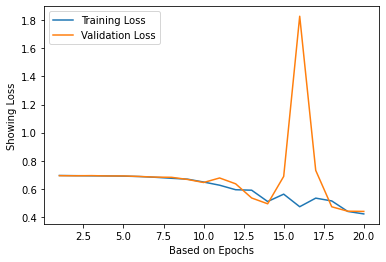

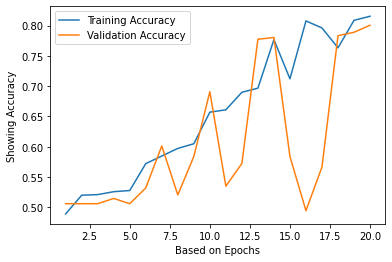

In [17]:
x_axis_range = range(1, num_epochs + 1)

plt.plot(x_axis_range, progress.history['loss'], label='Training Loss')
plt.plot(x_axis_range, progress.history['val_loss'], label='Validation Loss')

plt.xlabel('Based on Epochs')
plt.ylabel('Showing Loss')
plt.legend()
plt.show()

plt.plot(x_axis_range, progress.history['accuracy'], label='Training Accuracy')
plt.plot(x_axis_range, progress.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Based on Epochs')
plt.ylabel('Showing Accuracy')
plt.legend()
plt.show()

After tweaking the model parameters and improving the model's performance, let us see the performance it has on the test data. We will compare our model on training set vs how well it generalizes to data is has never seen. We will talk more about how we improved the model and what it still needs.

In [18]:
model_loss, model_acc = nn_model.evaluate(X_test_vector.toarray(), y_test)

print(f'Model Loss: {model_loss}')
print(f'Model Accuracy: {model_acc}')

19/19 [==============================] - 0s 2ms/step - loss: 0.4541 - accuracy: 0.7889
Model Loss: 0.4541413486003876
Model Accuracy: 0.7888513803482056


Our model makes predictions given a decimal from 0 to 1, as we used the output function of sigmoid. A sine wave goes from 0 to 1. We should test if our model actually works with certain examples instead of just checking its accuracy and visualizing the metrics. We will take about 10 examples and see if our model can tell if a review is True or False, or closer to 0 or 1, respectively. Our treshold will be the default set of 0.5. Let us print the class labels along with the decimal probability to check if our model is understanding the data.

In [21]:
prob_predict = nn_model.predict(X_test_vector.toarray())

numerical_label = y_test.to_numpy() # Converting a series to a numpy array so we can index into it

for i in range(10):
    probability = prob_predict[i][0]
    if probability > 0.5:
        print(f'Probability: {prob_predict[i]}')
        print(f'Numerical Label: {numerical_label[i]}')

Probability: [0.61901855]
Numerical Label: False
Probability: [0.7885771]
Numerical Label: True
Probability: [0.7412761]
Numerical Label: True
Probability: [0.6073298]
Numerical Label: False
Probability: [0.92857623]
Numerical Label: True
Probability: [0.8397068]
Numerical Label: True


## Examples

Let us now look at different examples of book reviews and see if they are positive or negative. This is a good way to understand if our model is doing good on semantic learning.

In [44]:
print('First Review: \n')
print(X_test.to_numpy()[400])

goodReview = True if prob_predict[5] >= 0.5 else False

print(f'\n What is real: {goodReview}')
print(f'\n Model Saying: {y_test.to_numpy()[5]}')

First Review: 

we love this book!  we have made many of the recipes that have all tasted great and are healthy.  we also gave it to everyone for christmas and they all love the recipes too


 What is real: True

 Model Saying: False


In [33]:
print('Second Review: \n')
print(X_test.to_numpy()[5])

goodReview = True if prob_predict[30] >= 0.5 else False

print(f'\n What is real: {goodReview}')
print(f'\n Model Saying: {y_test.to_numpy()[5]}')

Second Review: 

i bought this book before my first trip to austria. i had a 
sinking feeling while reading it that it was mostly a 
pastiche of unusable generalizations. that turned out to be
true. what shall we do with a paragraph that tells us that
austrian women are strong-minded and independent and 
organize their homelife well, although many go to work?

this book might have some value for a person who had never
left their english-speaking homeland before and needed to 
be warned that people are sometimes naked in the sauna
or at the beach. it also provides some amusing anecdotes
about language (especially viennese) and useful info about 
festivals.

mostly, though this book was good for reading aloud to
austrian friends. i would quote it as an iron-clad 
authority when their behavior didn't quite match the 
book's version and thereby amused them tremendously.


--lynn hoffman, author of the new short course in wine and
the forthcoming novel bang bang from kunati books.isbn
97816

In [34]:
print('Third Review: \n')
print(X_test.to_numpy()[5])

goodReview = True if prob_predict[10] >= 0.5 else False

print(f'\n What is real: {goodReview}')
print(f'\n Model Saying: {y_test.to_numpy()[5]}')

Third Review: 

i bought this book before my first trip to austria. i had a 
sinking feeling while reading it that it was mostly a 
pastiche of unusable generalizations. that turned out to be
true. what shall we do with a paragraph that tells us that
austrian women are strong-minded and independent and 
organize their homelife well, although many go to work?

this book might have some value for a person who had never
left their english-speaking homeland before and needed to 
be warned that people are sometimes naked in the sauna
or at the beach. it also provides some amusing anecdotes
about language (especially viennese) and useful info about 
festivals.

mostly, though this book was good for reading aloud to
austrian friends. i would quote it as an iron-clad 
authority when their behavior didn't quite match the 
book's version and thereby amused them tremendously.


--lynn hoffman, author of the new short course in wine and
the forthcoming novel bang bang from kunati books.isbn
978160

## Understanding
We can see that our model did get a lot better, but it still has a lot more it could do. I tried a lot of different parameter tunings and I came to these parameters as some of the best for our model. I can understand how hard neural network training is, as the hardest part of training this model was figuring out why it kept overfitting to the dataset. Even after adding another hidden layer, it would sometimes go back to overfitting seemingly out of nowhere. I figured out that I can use different activation functions to help the accuracy for the model, add more units per each layer, and for changing the epochs so that the model doesn't immediately overfit after just a few epochs.<br>
<b>Units:</b> 128, 64, 32, 16 going down for each hidden layer added.<br>
<b>Epochs:</b> 20 epochs for the model to train on.<br>
<b>Learning Rate:</b> 0.1<br>